In [1]:
import numpy as np
from scipy.optimize import minimize
from scipy.interpolate import CubicSpline
from scipy.sparse import diags
from scipy.sparse.linalg import eigsh
import matplotlib.pyplot as plt
from typing import Optional
from scipy.optimize import differential_evolution, minimize
import time

In [12]:
# ----------------------------
# Constants (SI)
# ----------------------------

h = 6.62607015e-34
hbar = h / (2.0 * np.pi)
e = 1.602176634e-19
Phi0 = h / (2.0 * e)

# ----------------------------
# Nonlinear branch energy f(phi, phi_e) and analytic derivatives
# phi is dimensionless phase; phi_e is external flux through both loops in total in units of Phi0 (dimensionless)
# here, phi_e is a 2-element array: phi_e[0] is the external flux for the first branch, phi_e[1] is the external flux for the second branch
# ----------------------------
def f(phi, phi_e, EL, EJ):
    return 0.5 * EL * phi**2 - EJ * np.cos(phi - 2 * np.pi * phi_e[1]) - EJ * np.cos(phi + 2 * np.pi * phi_e[0])

def df(phi, phi_e, EL, EJ):
    return EL * phi + EJ * np.sin(phi - 2 * np.pi * phi_e[1]) + EJ * np.sin(phi + 2 * np.pi * phi_e[0])

def d2f(phi, phi_e, EL, EJ):
    return EL + EJ * np.cos(phi - 2 * np.pi * phi_e[1]) + EJ * np.cos(phi + 2 * np.pi * phi_e[0])

# ----------------------------
# Full constrained potential:
# phi_total = phi1 + phi2 + ... + phiN, eliminate phi1 = phi_total - sum(phi_extra)
# x = phi_extra = [phi2, phi3, ..., phiN] has length N-1
# phi_e_array has length N is the external flux for each branch
# ----------------------------
def U_full(phi_total, x, phi_e_array, EL, EJ):
    phi1 = phi_total - np.sum(x)
    U = f(phi1, phi_e_array[0], EL, EJ)
    for i in range(x.size):
        U += f(x[i], phi_e_array[i + 1], EL, EJ)
    return U

def grad_U_full(phi_total, x, phi_e_array, EL, EJ):
    phi1 = phi_total - np.sum(x)
    df_phi1 = df(phi1, phi_e_array[0], EL, EJ)
    g = np.empty_like(x, dtype=float)
    for i in range(x.size):
        g[i] = -df_phi1 + df(x[i], phi_e_array[i + 1], EL, EJ)
    return g

def hess_U_full(phi_total, x, phi_e_array, EL, EJ):
    phi1 = phi_total - np.sum(x)
    a = d2f(phi1, phi_e_array[0], EL, EJ)  # all off-diagonal entries are a
    n = x.size
    H = np.full((n, n), a, dtype=float)
    for i in range(n):
        H[i, i] = a + d2f(x[i], phi_e_array[i + 1], EL, EJ)
    return H

# ----------------------------
# Minimization domain / periodicity for phase-like variables
# ----------------------------
phi_period = 2.0 * np.pi
phi_min_domain = -0.5 * phi_period
phi_max_domain =  0.5 * phi_period

# n_starts is the number of random restarts for global optimization; seed is for reproducibility
# phi_total is the coordinate we want to keep; x are the extra coordinates we minimize out
# phi_e_array is the external flux for each branch (length N_potential), this is fixed for the whole optimization
def minimize_phi_extra(phi_total, phi_e_array, x0, N_potential, EL, EJ, n_starts, seed, options = None):
    rng = np.random.default_rng(seed)
    n_extra = N_potential - 1

    # objective / derivatives for scipy
    def obj(x):
        return float(U_full(phi_total, x, phi_e_array, EL, EJ))

    def jac(x):
        return grad_U_full(phi_total, x, phi_e_array, EL, EJ)

    def hess(x):
        return hess_U_full(phi_total, x, phi_e_array, EL, EJ)

    best_x = None
    best_fun = np.inf

    # random-restart global search: sample x0 uniformly, run local minimizer, keep best
    for i in range(n_starts):
        if i == 0 and x0 is not None:
            x0 = np.array(x0, dtype=float)
        else:
            x0 = rng.uniform(phi_min_domain, phi_max_domain, size=n_extra)

        res = minimize(
            obj,
            x0,
            method="trust-exact",      # uses analytic jac + hess
            jac=jac,
            hess=hess,
            options=options,
        )

        if res.fun < best_fun:
            best_fun = float(res.fun)
            best_x = np.array(res.x, dtype=float)
    
    best_x = np.mod(best_x - phi_min_domain, phi_period) + phi_min_domain

    return best_x, best_fun

# ----------------------------
# Compute the effective 1D potential U_eff(phi_total) by minimizing out internal degrees of freedom
# 
# This performs a "Born-Oppenheimer" approximation: at each value of the total flux phi_total,
# we minimize over the internal flux distributions [phi2, phi3, ..., phiN] to find the 
# ground-state energy. This reduces the N-dimensional problem to an effective 1D problem.
#
# The result U_eff(phi_total) is the potential energy surface that the system sees when 
# the internal coordinates have relaxed to their optimal configuration.
# ----------------------------

# phi_grid is the array of total flux values we want to evaluate U_eff at
# phi_e_array is the external flux for each branch (length N_potential), this is fixed
# N_potential is the total number of branches (including phi1), EL and EJ are the energy scales
def compute_Ueff(phi_grid, phi_e_array, N_potential, EL, EJ, n_starts, seed, options=None):
    # Pre-allocate arrays to store results at each grid point
    Ueff = np.empty_like(phi_grid, dtype=float)                      # effective 1D potential energy
    x_star = np.empty((phi_grid.size, N_potential - 1), dtype=float) # optimal internal coordinates. Row i is the optimal [phi2, phi3, ..., phiN] for phi_total = phi_grid[i]
    
    # Warm-start optimization: use previous point's solution as initial guess for next point
    # This helps the optimizer follow the same energy minimum branch smoothly along phi_total
    x_prev = None
    
    for i, phi_total in enumerate(phi_grid):
        # Minimize U_full over internal coordinates x = [phi2, ..., phiN] at fixed phi_total
        x_opt, U_opt = minimize_phi_extra(phi_total, phi_e_array, x_prev, N_potential, EL, EJ, n_starts, seed, options=options)
        
        # Store the minimized energy and optimal internal coordinates
        x_star[i, :] = x_opt   # optimal flux distribution at this phi_total
        Ueff[i] = U_opt        # minimum energy = effective potential
        
        # Use this solution to initialize the next optimization step (warm start)
        x_prev = x_opt
    
    return Ueff, x_star

# ----------------------------
# Diagonalize the 1D quantum Hamiltonian H = 4*EC*n^2 + U_eff(phi) using finite differences
#
# The number operator n = -i*d/dphi becomes a discretized derivative, so the kinetic energy
# 4*EC*n^2 = -4*EC*d²/dphi² is represented by a finite-difference Laplacian matrix.
#
# We impose Dirichlet (zero) boundary conditions: ψ(phi_min) = ψ(phi_max) = 0
# This is appropriate when U_eff → ∞ at the boundaries, confining the wavefunction.
#
# order=3: Standard 3-point stencil (2nd-order accurate), gives tridiagonal matrix
# order=5: Higher-accuracy 5-point stencil (4th-order accurate), gives pentadiagonal matrix
# ----------------------------
def diagonalize_fd(phi_grid, Ueff, EC, n_levels, order):
    dphi = phi_grid[1] - phi_grid[0]  # uniform grid spacing
    
    # Enforce Dirichlet (zero) boundary conditions by excluding boundary points
    # We only solve for the wavefunction at interior points: phi_grid[1:-1]
    U_in = Ueff[1:-1]  # potential on interior points, excludes the two boundaries where ψ=0
    N = U_in.size      # number of interior points
    
    # KE and U_in properly account for the potential = 0 at boundaries
    if order == 3: 
        # Standard 3-point centered difference: ψ'' ≈ (ψ_{i-1} - 2ψ_i + ψ_{i+1})/dphi²
        # Kinetic energy: -4*EC*d²/dphi² → diagonal: +8*EC/dphi², off-diag: -4*EC/dphi²
        main = (8.0 * EC / dphi**2) + U_in      # diagonal: kinetic + potential
        off1 = (-4.0 * EC / dphi**2) * np.ones(N - 1)  # nearest-neighbor coupling due to kinetic energy
        H = diags([off1, main, off1], offsets=[-1, 0, 1], format="csc")
    
    elif order == 5:
        # 5-point stencil for higher accuracy (4th-order in interior):
        # ψ'' ≈ (-ψ_{i+2} + 16ψ_{i+1} - 30ψ_i + 16ψ_{i-1} - ψ_{i-2}) / (12*dphi²)
        # Multiply by -4*EC to get kinetic energy operator coefficients
        c0 = (10.0 * EC / dphi**2)             # diagonal (note: 30/12 * 4 = 10)
        c1 = (-16.0 * EC / (3.0 * dphi**2))    # ±1 neighbors (16/12 * 4 = 16/3)
        c2 = (1.0 * EC / (3.0 * dphi**2))      # ±2 neighbors (1/12 * 4 = 1/3)
        
        main = c0 + U_in                       # diagonal: kinetic + potential
        off1 = c1 * np.ones(N - 1)            # nearest neighbors
        off2 = c2 * np.ones(N - 2)            # next-nearest neighbors
        H = diags([off2, off1, main, off1, off2], offsets=[-2, -1, 0, 1, 2], format="csc")
    
    else:
        raise ValueError("order must be 3 or 5")
    
    # Find the lowest n_levels eigenstates using sparse eigenvalue solver
    # "SA" = smallest algebraic eigenvalues (ground state and low-lying excited states)
    evals, evecs = eigsh(H, k=n_levels, which="SA")
    
    # Sort eigenvalues in ascending order (should already be sorted, but ensure it)
    idx = np.argsort(evals)
    
    return evals[idx], evecs[:, idx]

def full_analysis(phi_total_mag, N_opt, N_fine, phi_e_array, N_potential, EL, EJ, EC, n_levels, order: Optional[int] = 5, n_starts: Optional[int] = 3, seed: Optional[int] = 0, options: Optional[dict] = {"maxiter": 200, "gtol": 1e-8}):

    # coarse grid for minimizing out extra coordinates (expensive)
    phi_total_min = -phi_total_mag * 2 * np.pi
    phi_total_max =  phi_total_mag * 2 * np.pi
    phi_opt = np.linspace(phi_total_min, phi_total_max, N_opt)

    Ueff_opt, x_star = compute_Ueff(phi_opt, phi_e_array, N_potential, EL, EJ, n_starts, seed, options=options)

    # spline onto a finer grid for diagonalization (cheap)
    phi_fine = np.linspace(phi_total_min, phi_total_max, N_fine)
    U_spline = CubicSpline(phi_opt, Ueff_opt, bc_type="natural")
    Ueff_fine = U_spline(phi_fine)

    # diagonalize with non-periodic boundaries
    E_GHz, V = diagonalize_fd(phi_fine, Ueff_fine, EC, n_levels, order)

    return {'phi_fine' : phi_fine, 'Ueff_fine' : Ueff_fine, 'phi_opt' : phi_opt, 'Ueff_opt': Ueff_opt, 'E_GHz' : E_GHz, 'V' : V, 'N_opt' : N_opt, 'N_fine' : N_fine, 'phi_total_min' : phi_total_min, 'phi_total_max' : phi_total_max, 'x_star' : x_star}

def get_freq_vs_flux(phi_e_initial, phi_ext_sweep, phi_total_mag, N_opt, N_fine, N_potential, EL, EJ, EC, n_levels, order: Optional[int] = 5, n_starts: Optional[int] = 1, seed: Optional[int] = 0, options: Optional[dict] = {"maxiter": 200, "gtol": 1e-9}):
    phi_e_initial = np.array(phi_e_initial, dtype=float) # make sure array

    Ueff_fine_sweep_all = np.empty((len(phi_ext_sweep), N_fine), dtype=float)  # store U_eff for all flux points
    E_sweep = np.empty((len(phi_ext_sweep), n_levels), dtype=float)  # store energy levels for all flux points

    print("Running flux sweep...")
    for i, phi_ext in enumerate(phi_ext_sweep):
        # Set external flux for each branch: initial offset + overall flux
        phi_e_array_sweep = phi_e_initial + phi_ext/2 # divide by 2 because each branch sees half the total flux
        
        # Compute effective potential
        result = full_analysis(
        phi_total_mag=phi_total_mag, 
        N_opt=N_opt, 
        N_fine=N_fine, 
        phi_e_array=phi_e_array_sweep, 
        N_potential=N_potential, 
        EL=EL, 
        EJ=EJ, 
        EC=EC, 
        n_levels=n_levels, 
        order=order, 
        n_starts=n_starts, 
        seed=seed,
        options=options)
        
        Ueff_fine_sweep_all[i, :] = result["Ueff_fine"]  # store for later plotting
        E_sweep[i, :] = result["E_GHz"]  # store energy levels for this flux point

        if (i + 1) % 10 == 0:
            print(f"  Completed {i+1}/{len(phi_ext_sweep)} flux points")
    print("Flux sweep completed!\n")

    return {'Ueff_fine_sweep_all': Ueff_fine_sweep_all, 'E_sweep': E_sweep}

def quantum_local_optimization(N_potential, DC_x, f01_data_GHz, points, bounds, initial_guess, phi_total_mag, N_opt_fit, N_fine_fit, n_levels_fit, order, n_starts, seed, options_full_analysis, options_optimizer):
    DC_x = DC_x[::points]
    f01_data_GHz = f01_data_GHz[::points]

    eval_count = [0]       # mutable counter for progress printing

    def cost_function(params):
        phi_e_init = np.array(params[:N_potential * 2]).reshape(N_potential, 2)
        EL = params[N_potential * 2]
        EL_EJ_ratio = params[N_potential * 2 + 1]         # EL/EJ ratio
        EC = params[N_potential * 2 + 2]                      # charging energy (GHz)

        EJ = EL / EL_EJ_ratio                         # Josephson energy from fixed ratio

        f01_sweep = np.zeros(len(DC_x))
        for j, phi_ext in enumerate(DC_x):
            # Each branch sees its own offset + the global sweep flux
            phi_e_array = phi_e_init + phi_ext/2 # divide by 2 because each branch sees half the total flux

            result = full_analysis(
                phi_total_mag=phi_total_mag,
                N_opt=N_opt_fit,
                N_fine=N_fine_fit,
                phi_e_array=phi_e_array,
                N_potential=N_potential,
                EL=EL, EJ=EJ, EC=EC,
                n_levels=n_levels_fit,
                order=order,
                n_starts=n_starts,
                seed=seed,
                options=options_full_analysis
            )
            f01_sweep[j] = result['E_GHz'][1] - result['E_GHz'][0]

        # Least-squares residual
        residual = np.sum((f01_sweep - f01_data_GHz) ** 2)

        # Progress reporting
        eval_count[0] += 1
        if eval_count[0] % 5 == 0:
            rms_MHz = np.sqrt(residual / len(DC_x)) * 1e3
            print(f"   Eval {eval_count[0]:4d}:   RMS = {rms_MHz:.1f} MHz   "
                f"EL = {EL:.2f}   EL/EJ = {EL_EJ_ratio:.2f}")

        return residual
    
    opt_result = minimize(cost_function, x0=initial_guess, bounds=bounds, method='L-BFGS-B', options=options_optimizer)

    phi_e_opt = opt_result.x[:N_potential * 2].reshape(N_potential, 2)
    EL_opt    = opt_result.x[N_potential * 2]
    EC_opt = opt_result.x[N_potential * 2 + 2]
    EL_EJ_ratio_opt = opt_result.x[N_potential * 2 + 1]
    EJ_opt    = EL_opt / EL_EJ_ratio_opt

    return {'phi_e_initial_opt': phi_e_opt, 'EL_opt': EL_opt, 'EJ_opt': EJ_opt, 'EL_EJ_ratio_opt': EL_EJ_ratio_opt, 'EC_opt': EC_opt, 'opt_result': opt_result}
    
def classical_freq(phi_e_array, EC, EL, EJ):
    phi_e_array = np.array(phi_e_array, dtype=float)   # (N,2)

    Sigma = phi_e_array[:, 0] + phi_e_array[:, 1]
    Delta = phi_e_array[:, 0] - phi_e_array[:, 1]

    k_array = EL + 2.0 * EJ * np.cos(np.pi * Sigma) * np.cos(np.pi * Delta)
    k_eff = 1.0 / np.sum(1.0 / k_array)

    return np.sqrt(8.0 * EC * k_eff)

def classical_freq_exact(phi_e_array, EC, EL, EJ, n_iter):
    phi_e_array = np.array(phi_e_array, dtype=float)   # (N,2)
    phi0 = 0.0                                         # good default for EL ~ few*EJ

    Sigma = phi_e_array[:, 0] + phi_e_array[:, 1]
    Delta = phi_e_array[:, 0] - phi_e_array[:, 1]

    # rewrite branch potential exactly:
    # f(phi) = 0.5*EL*phi^2 - 2*EJ*cos(pi*Sigma)*cos(phi + pi*Delta)
    A = 2.0 * EJ * np.cos(np.pi * Sigma)               # amplitude
    s = np.pi * Delta                                  # phase shift

    # Newton solve for each branch equilibrium: EL*phi + A*sin(phi+s) = 0
    phi = np.full_like(Sigma, phi0, dtype=float)

    for _ in range(n_iter):
        g  = EL * phi + A * np.sin(phi + s)            # df
        gp = EL + A * np.cos(phi + s)                  # d2f
        phi -= g / gp

    # exact curvature at the found equilibrium (this is d2f at phi*)
    k_array = EL + A * np.cos(phi + s)

    k_eff = 1.0 / np.sum(1.0 / k_array)
    return np.sqrt(8.0 * EC * k_eff)

def classical_freq_function_of_flux(phi_e_initial, phi_e_apply, EC, EL, EJ, mode, n_iter):
    phi_e_initial = np.array(phi_e_initial, dtype=float)  # (N,2)
    freq_array = np.zeros_like(phi_e_apply, dtype=float)

    for i, phi_ext in enumerate(phi_e_apply):
        phi_e_array = phi_e_initial + phi_ext / 2.0

        if mode == "approx":
            freq_array[i] = classical_freq(phi_e_array, EC, EL, EJ)
        elif mode == "exact":
            freq_array[i] = classical_freq_exact(phi_e_array, EC, EL, EJ, n_iter)
        else:            
            raise ValueError("mode must be 'approx' or 'exact'")

    return freq_array


def classical_optimization(N_potential, EC, DC_x, f01_data_GHz, points, bounds, maxiter, popsize, tol, mutation, recombination, seed, mode, n_iter):
    DC_x = DC_x[::points]
    f01_data_GHz = f01_data_GHz[::points]

    eval_count = [0]       # mutable counter for progress printing

    def cost_function(params):
        phi_e_init = np.array(params[:N_potential * 2]).reshape(N_potential, 2)
        EL = params[N_potential * 2]
        EL_EJ_ratio = params[N_potential * 2 + 1]         # EL/EJ ratio
        EJ = EL / EL_EJ_ratio                         # Josephson energy from variable ratio

        f01_sweep = classical_freq_function_of_flux(phi_e_initial=phi_e_init, phi_e_apply=DC_x, EL=EL, EJ=EJ, EC=EC, mode=mode, n_iter=n_iter)

        # Least-squares residual
        residual = np.sum((f01_sweep - f01_data_GHz) ** 2)

        # Progress reporting
        eval_count[0] += 1
  
        if eval_count[0] % 1000 == 0:
            rms_MHz = np.sqrt(residual / len(DC_x)) * 1e3
            print(f"   Eval {eval_count[0]:4d}:   RMS = {rms_MHz:.1f} MHz   "
                f"EL = {EL:.2f}   EL/EJ = {EL_EJ_ratio:.2f}")
        return residual

    opt_result = differential_evolution(
        cost_function,
        bounds,
        maxiter=maxiter,             # max number of generations
        popsize=popsize,             # individuals per parameter dimension
        tol=tol,               # relative convergence tolerance
        mutation=mutation,    # differential weight (dithered for robustness)
        recombination= recombination,      # crossover probability
        seed=seed,          # for reproducibility
        disp=True,              # print generation-level progress
        polish=True,            # local refinement after DE converges
    )

    # =====================================================================
    # Extract and display optimized parameters
    # =====================================================================

    phi_e_opt = opt_result.x[:N_potential * 2].reshape(N_potential, 2)
    EL_opt    = opt_result.x[N_potential * 2]
    EL_EJ_ratio_opt = opt_result.x[N_potential * 2 + 1]
    EJ_opt    = EL_opt / EL_EJ_ratio_opt

    print("\n" + "=" * 70)
    print("OPTIMIZATION RESULTS")
    print("=" * 70)
    print(f"  phi_e_initial = [{phi_e_opt[0]:.6f}, {phi_e_opt[1]:.6f}, {phi_e_opt[2]:.6f}] Phi_0")
    print(f"  EL = {EL_opt:.4f} GHz")
    print(f"  EJ = {EJ_opt:.4f} GHz")
    print(f"  EC = {EC} GHz (fixed)")
    print(f"  EL/EJ = {EL_EJ_ratio_opt:.4f} (variable)")
    print(f"  Residual = {opt_result.fun:.6f} GHz²")
    print(f"  RMS error = {np.sqrt(opt_result.fun / len(DC_x)) * 1e3:.1f} MHz")
    print(f"  Function evaluations = {opt_result.nfev}")
    print(f"  Converged: {opt_result.success}  ({opt_result.message})")

    return {'phi_e_initial_opt': phi_e_opt, 'EL_opt': EL_opt, 'EJ_opt': EJ_opt, 'EL_EJ_ratio_opt': EL_EJ_ratio_opt, 'opt_result': opt_result}

# Frequency vs Flux

Running flux sweep...
  Completed 10/40 flux points
  Completed 20/40 flux points
  Completed 30/40 flux points
  Completed 40/40 flux points
Flux sweep completed!



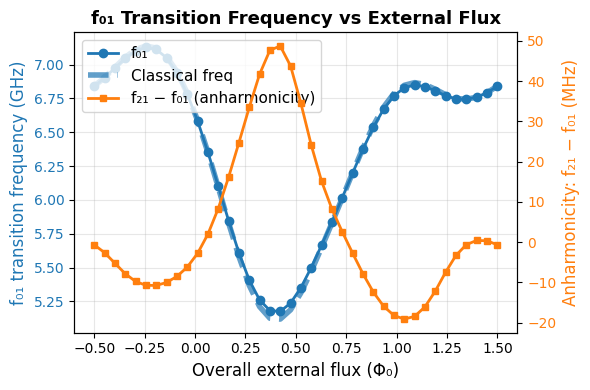

In [44]:
N_potential = 3  # total number of branches in U = sum_i f(phi_i, phi_ei)

freq = 6.5 # in GHz, at kerr free point
EL_EJ_ratio = 3

EC = 0.13
EL_eff_target = freq**2 / (8*EC)     # what the *effective* quadratic coefficient should be
EL = N_potential * EL_eff_target     # branch EL so that EL_eff = EL/N_potential = EL_eff_target
EJ = EL / EL_EJ_ratio

phi_e_initial = [[-0.6, 0.7], [0.9, -0.9], [0.3, -0.7]]
phi_ext_sweep = np.linspace(-0.5, 1.5, 40)

E_sweep_classical = classical_freq_function_of_flux(phi_e_initial, phi_ext_sweep, EC, EL, EJ, mode="exact", n_iter=3)  # compute classical frequencies for the whole sweep

quantum_result = get_freq_vs_flux(phi_e_initial = phi_e_initial, phi_ext_sweep = phi_ext_sweep, phi_total_mag=2.0, N_opt=40, N_fine=1000, N_potential=N_potential, EL=EL, EJ=EJ, EC=EC, n_levels=3, order=5, n_starts=1, seed=0, options={"maxiter": 100, "gtol": 1e-9})
E_sweep = quantum_result['E_sweep']

f01 = E_sweep[:, 1] - E_sweep[:, 0]
# Plot f_01 transition frequency vs external flux
fig, ax = plt.subplots(figsize=(6, 4))

# Plot f_01 (ground to first excited) on left axis
f01 = E_sweep[:, 1] - E_sweep[:, 0]
ax.plot(phi_ext_sweep, f01, '-o', linewidth=2, markersize=6, color='C0', label='f₀₁')
ax.plot(phi_ext_sweep, E_sweep_classical, '--', linewidth=4, color='C0', alpha=0.7, label='Classical freq')

ax.set_xlabel('Overall external flux (Φ₀)', fontsize=12)
ax.set_ylabel('f₀₁ transition frequency (GHz)', fontsize=12, color='C0')
ax.tick_params(axis='y', labelcolor='C0')
ax.set_title('f₀₁ Transition Frequency vs External Flux', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)

# Create second y-axis for anharmonicity
ax2 = ax.twinx()

# Plot anharmonicity (f_21 - f_01) on right axis
f21 = E_sweep[:, 2] - E_sweep[:, 1]
anharmonicity = f21 - f01
ax2.plot(phi_ext_sweep, anharmonicity * 1e3, '-s', linewidth=2, markersize=5, color='C1', label='f₂₁ − f₀₁ (anharmonicity)')

ax2.set_ylabel('Anharmonicity: f₂₁ − f₀₁ (MHz)', fontsize=12, color='C1')
ax2.tick_params(axis='y', labelcolor='C1')

# Combine legends
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=11, loc='upper left')

plt.tight_layout()
plt.show()

# Data L1 and classical optimization

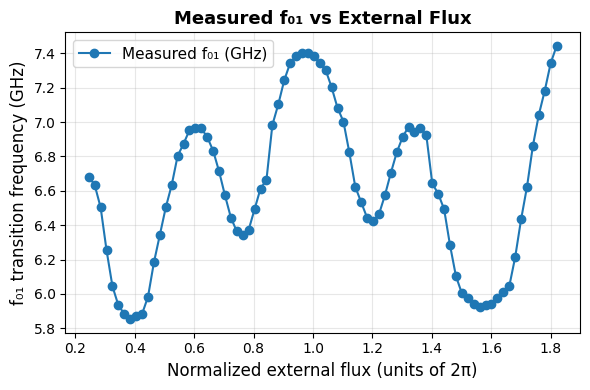

   Eval 1000:   RMS = 2175.2 MHz   EL = 225.60   EL/EJ = 14.45
   Eval 2000:   RMS = 1438.0 MHz   EL = 186.88   EL/EJ = 13.37
   Eval 3000:   RMS = 1034.4 MHz   EL = 171.81   EL/EJ = 6.76
   Eval 4000:   RMS = 720.8 MHz   EL = 116.18   EL/EJ = 7.34
   Eval 5000:   RMS = 3032.7 MHz   EL = 271.49   EL/EJ = 14.45
   Eval 6000:   RMS = 1384.8 MHz   EL = 186.88   EL/EJ = 13.37
   Eval 7000:   RMS = 1857.8 MHz   EL = 69.79   EL/EJ = 5.74
   Eval 8000:   RMS = 1781.2 MHz   EL = 202.43   EL/EJ = 7.34
differential_evolution step 1: f(x)= 12.284252968923912
   Eval 9000:   RMS = 941.2 MHz   EL = 156.90   EL/EJ = 3.56
   Eval 10000:   RMS = 730.7 MHz   EL = 107.13   EL/EJ = 13.37
   Eval 11000:   RMS = 1086.1 MHz   EL = 171.81   EL/EJ = 6.76
   Eval 12000:   RMS = 497.3 MHz   EL = 116.18   EL/EJ = 4.54
differential_evolution step 2: f(x)= 9.777051528721206
   Eval 13000:   RMS = 816.6 MHz   EL = 124.13   EL/EJ = 3.56
   Eval 14000:   RMS = 545.2 MHz   EL = 112.15   EL/EJ = 5.80
   Eval 15000:   R

KeyboardInterrupt: 

In [46]:
flux_npi = -3.2     # raw flux value corresponding to -pi
flux_pi  = 2.65     # raw flux value corresponding to +pi
period   = flux_pi - flux_npi  # one full period in raw units

# Raw DC flux points (coil units)
DC_x = np.array([-2.4833, -2.425, -2.3667, -2.3083, -2.25, -2.1917, -2.1333,
        -2.0750, -2.0167, -1.9583, -1.90, -1.8417, -1.7833, -1.725,
        -1.6667, -1.6083, -1.55, -1.4917, -1.4333, -1.375, -1.3167,
         -1.2583, -1.2, -1.1417, -1.0833, -1.025, -0.9667, -0.9083,
        -0.85, -0.7917, -0.7333, -0.675, -0.6167, -0.5583, -0.5,
        -0.4417, -0.3833, -0.325, -0.2667, -0.2083, -0.15, -0.0917,
        -0.0333, 0.025, 0.0833, 0.1417, 0.2, 0.2583, 0.3167, 0.375,
        0.4333, 0.4917, 0.55, 0.6083, 0.6667, 0.725, 0.7833, 0.8417,
        0.9, 0.9583, 1.0167, 1.075, 1.1333, 1.1917, 1.25, 1.3083,
        1.3667, 1.425, 1.4833, 1.5417, 1.6, 1.6583, 1.7167, 1.775,
        1.8333, 1.8917, 1.95, 2.0083, 2.0667, 2.125])

# Normalize: map one period → 2 (same periodicity as cos(π φ_e) in simulation)
DC_x = (DC_x - flux_npi) / period * 2

# Measured coupler frequency (Hz); some are half-frequency × 2
peak_point = np.array([2.3e9, 2.25e9, 2.12e9, 1.87e9, 1.66e9, 1.55e9, 1.5e9,
              1.47e9, 1.49e9, 1.50e9, 1.60e9, 1.8e9, 1.96e9, 2.12e9,
              2.25e9, 2.42e9, 2.49e9, 2.57e9, 2.58e9, 2.58e9, 2.53e9,
              2.45e9, 2.33e9, 2.19e9, 2.06e9, 1.98e9, 1.96e9, 1.99e9,
              2.11e9, 2.23e9, 2.28e9, 1.3e9*2, 1.36e9*2, 1.43e9*2, 1.48e9*2,
              1.5e9*2, 1.51e9*2, 1.51e9*2, 1.50e9*2, 1.48e9*2, 1.46e9*2, 1.41e9*2,
              1.35e9*2, 2.62e9, 2.44e9, 2.24e9, 2.15e9, 2.06e9, 2.04e9, 2.08e9,
              2.19e9, 2.32e9, 2.44e9, 2.53e9, 2.59e9, 1.28e9*2, 2.58e9, 2.54e9,
              2.26e9, 2.2e9, 2.11e9, 1.9e9, 1.72e9, 1.62e9, 1.59e9, 1.56e9,
              1.54e9, 1.55e9, 1.56e9, 1.59e9, 1.63e9, 1.66e9, 1.83e9, 2.05e9,
              2.24e9, 2.48e9, 1.33e9*2, 1.4e9*2, 1.48e9*2, 1.53e9*2]) + 4383.375200045928e6

# Convert to GHz (same units as simulation output)
f01_data_GHz = peak_point / 1e9

plt.figure(figsize=(6, 4))
plt.plot(DC_x, f01_data_GHz, 'o-', label='Measured f₀₁ (GHz)', color='C0')
plt.xlabel('Normalized external flux (units of 2π)', fontsize=12)
plt.ylabel('f₀₁ transition frequency (GHz)', fontsize=12)
plt.title('Measured f₀₁ vs External Flux', fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

result_data1 = classical_optimization(
        N_potential=3,
        EC=0.126,
        DC_x=DC_x,
        f01_data_GHz=f01_data_GHz,
        points = 1,  # use all points
        bounds=[(-1.0, 1.0), (-1.0, 1.0), (-1.0, 1.0), (-1.0, 1.0), (-1.0, 1.0), (-1.0, 1.0), (50, 300), (2, 15)],  # bounds for [phi_e_initial 6 of them, EL, EL/EJ]
        maxiter=1000,    
        popsize=500,
        tol=1e-10,
        mutation=(0.5, 1),  # differential weight (dithered for robustness)
        recombination=0.7,   # crossover probability
        seed=0,
        mode="exact",
        n_iter=3
)

# Plot data with fit

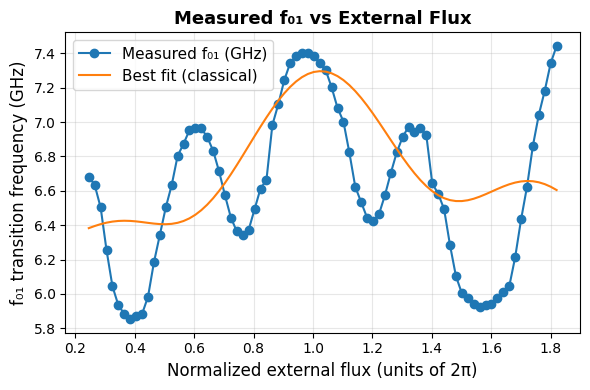

In [57]:
phi_e_opt = result_data1['phi_e_initial_opt']
EL_opt = result_data1['EL_opt']
EJ_opt = result_data1['EJ_opt']
EL_EJ_ratio_opt = result_data1['EL_EJ_ratio_opt']
figure = plt.figure(figsize=(6, 4))
plt.plot(DC_x, f01_data_GHz, 'o-', label='Measured f₀₁ (GHz)', color='C0')
plt.plot(DC_x, classical_freq_function_of_flux(phi_e_initial=phi_e_opt, phi_e_apply=DC_x, EL=EL_opt, EJ=EJ_opt, EC=EC), '-', label='Best fit (classical)', color='C1')
plt.xlabel('Normalized external flux (units of 2π)', fontsize=12)
plt.ylabel('f₀₁ transition frequency (GHz)', fontsize=12)
plt.title('Measured f₀₁ vs External Flux', fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

Running flux sweep...
  Completed 10/80 flux points
  Completed 20/80 flux points
  Completed 30/80 flux points
  Completed 40/80 flux points
  Completed 50/80 flux points
  Completed 60/80 flux points
  Completed 70/80 flux points
  Completed 80/80 flux points
Flux sweep completed!



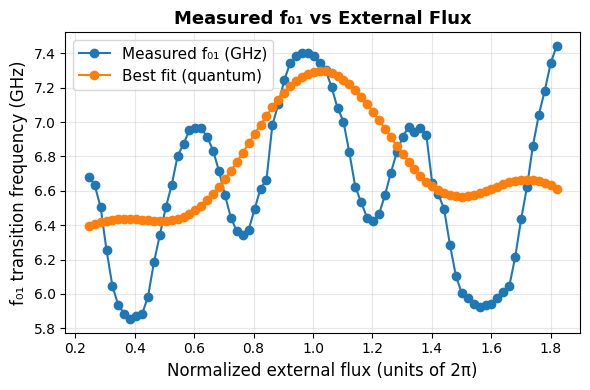

In [58]:
quantum_result_plot = get_freq_vs_flux(phi_e_initial = phi_e_opt, phi_ext_sweep = DC_x, phi_total_mag=2.0, N_opt=40, N_fine=1000, N_potential=N_potential, EL=EL_opt, EJ=EJ_opt, EC=EC, n_levels=3, order=5, n_starts=1, seed=0, options={"maxiter": 100, "gtol": 1e-9})
E_sweep = quantum_result_plot['E_sweep']

f01 = E_sweep[:, 1] - E_sweep[:, 0]
figure = plt.figure(figsize=(6, 4))
plt.plot(DC_x, f01_data_GHz, 'o-', label='Measured f₀₁ (GHz)', color='C0')
plt.plot(DC_x, f01, '-o', label='Best fit (quantum)', color='C1')
plt.xlabel('Normalized external flux (units of 2π)', fontsize=12)
plt.ylabel('f₀₁ transition frequency (GHz)', fontsize=12)
plt.title('Measured f₀₁ vs External Flux', fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

In [59]:
quantum_optimize_result = quantum_local_optimization(
    N_potential=3,
    EC=0.126,
    DC_x=DC_x,
    f01_data_GHz=f01_data_GHz,
    points=2,
    bounds=[(-1.0, 1.0), (-1.0, 1.0), (-1.0, 1.0), (100, 400), (2, 15)],  # bounds for [phi_e_initial 3 of them, EL, EL/EJ]
    initial_guess=[phi_e_opt[0], phi_e_opt[1], phi_e_opt[2], EL_opt, EL_EJ_ratio_opt],
    phi_total_mag=2.0,
    N_opt_fit=15,
    N_fine_fit=400,
    n_levels_fit=2,
    order=5,
    n_starts=1,
    seed=0,
    options_full_analysis={"maxiter": 100, "gtol": 1e-7},
    options_optimizer={"maxfun": 200, "gtol": 1e-7}
)

phi_e_initial_opt = quantum_optimize_result['phi_e_initial_opt']
EL_opt = quantum_optimize_result['EL_opt']
EJ_opt = quantum_optimize_result['EJ_opt']
EL_EJ_ratio_opt = quantum_optimize_result['EL_EJ_ratio_opt']

  Eval    5:  RMS = 371.8 MHzEL = 150.00   EL/EJ = 3.79
  Eval   10:  RMS = 936.9 MHzEL = 149.99   EL/EJ = 4.15
  Eval   15:  RMS = 371.7 MHzEL = 150.00   EL/EJ = 3.80
  Eval   20:  RMS = 371.5 MHzEL = 150.00   EL/EJ = 3.80
  Eval   25:  RMS = 371.4 MHzEL = 150.00   EL/EJ = 3.80
  Eval   30:  RMS = 371.4 MHzEL = 150.00   EL/EJ = 3.80
  Eval   35:  RMS = 371.4 MHzEL = 150.00   EL/EJ = 3.80
  Eval   40:  RMS = 371.3 MHzEL = 150.00   EL/EJ = 3.81
  Eval   45:  RMS = 371.3 MHzEL = 150.00   EL/EJ = 3.83
  Eval   50:  RMS = 371.3 MHzEL = 150.00   EL/EJ = 3.83
  Eval   55:  RMS = 371.3 MHzEL = 150.00   EL/EJ = 3.83
  Eval   60:  RMS = 371.3 MHzEL = 150.00   EL/EJ = 3.83
  Eval   65:  RMS = 371.3 MHzEL = 149.99   EL/EJ = 3.83
  Eval   70:  RMS = 371.3 MHzEL = 149.99   EL/EJ = 3.84
  Eval   75:  RMS = 371.2 MHzEL = 149.97   EL/EJ = 3.84
  Eval   80:  RMS = 371.2 MHzEL = 149.93   EL/EJ = 3.84
  Eval   85:  RMS = 371.1 MHzEL = 149.77   EL/EJ = 3.86
  Eval   90:  RMS = 371.1 MHzEL = 149.77   EL/EJ

Running flux sweep...
  Completed 10/80 flux points
  Completed 20/80 flux points
  Completed 30/80 flux points
  Completed 40/80 flux points
  Completed 50/80 flux points
  Completed 60/80 flux points
  Completed 70/80 flux points
  Completed 80/80 flux points
Flux sweep completed!



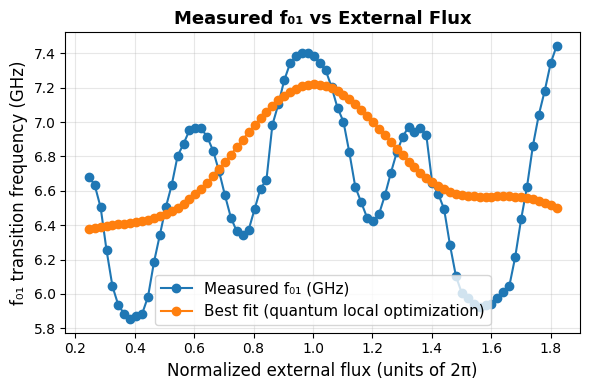

In [60]:
quantum_result = get_freq_vs_flux(phi_e_initial = phi_e_initial_opt, phi_ext_sweep = DC_x, phi_total_mag=2.0, N_opt=40, N_fine=1000, N_potential=N_potential, EL=EL_opt, EJ=EJ_opt, EC=EC, n_levels=3, order=5, n_starts=1, seed=0, options={"maxiter": 100, "gtol": 1e-9})
E_sweep = quantum_result['E_sweep']
f01 = E_sweep[:, 1] - E_sweep[:, 0]
figure = plt.figure(figsize=(6, 4))
plt.plot(DC_x, f01_data_GHz, 'o-', label='Measured f₀₁ (GHz)', color='C0')
plt.plot(DC_x, f01, '-o', label='Best fit (quantum local optimization)', color='C1')
plt.xlabel('Normalized external flux (units of 2π)', fontsize=12)
plt.ylabel('f₀₁ transition frequency (GHz)', fontsize=12)
plt.title('Measured f₀₁ vs External Flux', fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

# Data L2

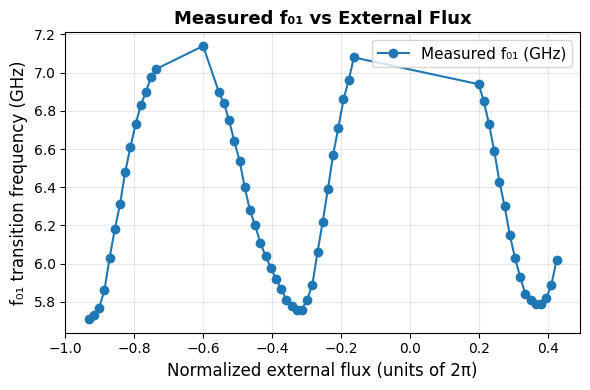

   Eval 1000:   RMS = 3342.2 MHz   EL = 235.12   EL/EJ = 2.96
   Eval 2000:   RMS = 2913.1 MHz   EL = 227.38   EL/EJ = 2.87
   Eval 3000:   RMS = 2654.3 MHz   EL = 224.36   EL/EJ = 2.37
   Eval 4000:   RMS = 2433.3 MHz   EL = 213.24   EL/EJ = 2.41


KeyboardInterrupt: 

In [6]:
flux_npi = 1.75
period = 2.81+3.09

DC_x = np.array([-1.0, -0.9556, -0.9111, -0.8667, -0.8222, -0.7778, -0.7333, -0.6889, -0.6444, -0.6, \
                 -0.5556, -0.5111, -0.4667, -0.4222, -0.0222, 0.1111, 0.1556, 0.2, 0.2444, 0.2889, \
                 0.3333, 0.3778, 0.4222, 0.4667, 0.5111, 0.5556, 0.6, 0.6444, 0.6889, 0.7333, 0.7778, \
                 0.8222, 0.8667, 0.9111, 0.9556, 1.0, 1.0444, 1.0889, 1.1333, 1.1778, 1.222, 1.2667, \
                 2.333, 2.3778, 2.4222, 2.4667, 2.5111, 2.5556, 2.6, 2.6444, 2.6889, 2.7333, 2.7778, \
                 2.8222, 2.8667, 2.9111, 2.9556, 3.0])

DC_x = (DC_x-flux_npi)/period*2

peak_point = np.array([1.55e9, 1.57e9, 1.61e9, 1.7e9, 1.87e9, 2.02e9, 2.15e9, 2.32e9, 2.45e9, 2.57e9, \
                       2.67e9, 1.37e9*2, 1.41e9*2, 1.43e9*2, 1.49e9*2, 1.37e9*2, 2.68e9, 2.59e9, 2.48e9, 2.38e9, \
                       2.24e9, 2.12e9, 2.04e9, 1.95e9, 1.88e9, 1.82e9, 1.76e9, 1.71e9, 1.65e9, 1.62e9, 1.6e9, \
                       1.6e9, 1.65e9, 1.73e9, 1.9e9, 2.06e9, 2.23e9, 2.41e9, 2.55e9, 2.7e9, 1.4e9*2, 1.46e9*2, \
                       1.39e9*2, 2.69e9, 2.57e9, 2.43e9, 2.27e9, 2.14e9, 1.99e9, 1.87e9, 1.77e9, 1.68e9, 1.65e9, \
                       1.63e9, 1.63e9, 1.66e9, 1.73e9, 1.86e9])+4159.767997395101e+6

# Convert to GHz (same units as simulation output)
f01_data_GHz = peak_point / 1e9

plt.figure(figsize=(6, 4))
plt.plot(DC_x, f01_data_GHz, 'o-', label='Measured f₀₁ (GHz)', color='C0')
plt.xlabel('Normalized external flux (units of 2π)', fontsize=12)
plt.ylabel('f₀₁ transition frequency (GHz)', fontsize=12)
plt.title('Measured f₀₁ vs External Flux', fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

result_data2 = classical_optimization(
        N_potential=3,
        EC=0.126,
        DC_x=DC_x,
        f01_data_GHz=f01_data_GHz,
        points = 1,  # use all points
        bounds=[(-1.0, 1.0), (-1.0, 1.0), (-1.0, 1.0), (-1.0, 1.0), (-1.0, 1.0), (-1.0, 1.0), (200, 250), (2, 3)],  # bounds for [phi_e_initial 3 of them, EL, EL/EJ]
        maxiter=1000,    
        popsize=500,
        tol=1e-5,
        mutation=(0.5, 1),  # differential weight (dithered for robustness)
        recombination=0.7,   # crossover probability
        seed=0,
        mode = "exact",
        n_iter=3
)

In [7]:
phi_e_opt = result_data2['phi_e_initial_opt']
EL_opt = result_data2['EL_opt']
EJ_opt = result_data2['EJ_opt']
EL_EJ_ratio_opt = result_data2['EL_EJ_ratio_opt']
figure = plt.figure(figsize=(6, 4))
plt.plot(DC_x, f01_data_GHz, 'o-', label='Measured f₀₁ (GHz)', color='C0')
plt.plot(DC_x, classical_freq_function_of_flux(phi_e_initial=phi_e_opt, phi_e_apply=DC_x, EL=EL_opt, EJ=EJ_opt, EC=EC), '-', label='Best fit (classical)', color='C1')
plt.xlabel('Normalized external flux (units of 2π)', fontsize=12)
plt.ylabel('f₀₁ transition frequency (GHz)', fontsize=12)
plt.title('Measured f₀₁ vs External Flux', fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

NameError: name 'result_data2' is not defined

Running flux sweep...
  Completed 10/58 flux points
  Completed 20/58 flux points
  Completed 30/58 flux points
  Completed 40/58 flux points
  Completed 50/58 flux points
Flux sweep completed!



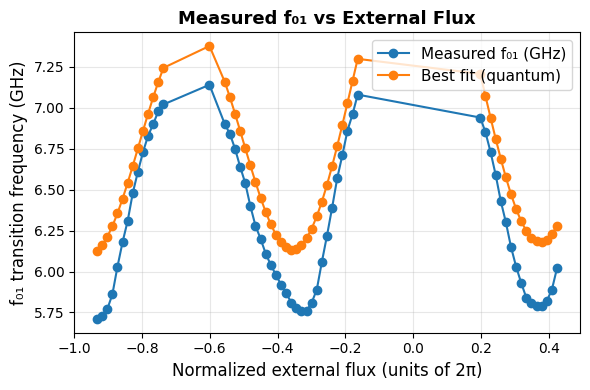

In [47]:
quantum_result_plot = get_freq_vs_flux(phi_e_initial = phi_e_opt, phi_ext_sweep = DC_x, phi_total_mag=2.0, N_opt=40, N_fine=1000, N_potential=N_potential, EL=EL_opt, EJ=EJ_opt, EC=EC, n_levels=3, order=5, n_starts=1, seed=0, options={"maxiter": 100, "gtol": 1e-9})
E_sweep = quantum_result_plot['E_sweep']

f01 = E_sweep[:, 1] - E_sweep[:, 0]
figure = plt.figure(figsize=(6, 4))
plt.plot(DC_x, f01_data_GHz, 'o-', label='Measured f₀₁ (GHz)', color='C0')
plt.plot(DC_x, f01, '-o', label='Best fit (quantum)', color='C1')
plt.xlabel('Normalized external flux (units of 2π)', fontsize=12)
plt.ylabel('f₀₁ transition frequency (GHz)', fontsize=12)
plt.title('Measured f₀₁ vs External Flux', fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

In [16]:
quantum_optimize_result = quantum_local_optimization(
    N_potential=3,
    DC_x=DC_x,
    f01_data_GHz=f01_data_GHz,
    points=2,
    bounds=[(-1.0, 1.0), (-1.0, 1.0), (-1.0, 1.0), (-1.0, 1.0), (-1.0, 1.0), (-1.0, 1.0), (150, 350), (2, 4), (0.07,0.3)],  # bounds for [phi_e_initial 3 of them, EL, EL/EJ]
    initial_guess=[ 0.62539041, 0.62539041, -0.0408485, -0.0408485,  -0.64709901, -0.64709901, 234.12, 2.34, 0.1327],
    phi_total_mag=2.0,
    N_opt_fit=15,
    N_fine_fit=400,
    n_levels_fit=2,
    order=5,
    n_starts=1,
    seed=0,
    options_full_analysis={"maxiter": 100, "gtol": 1e-7},
    options_optimizer={"maxfun": 300, "gtol": 1e-7}
)

phi_e_initial_opt = quantum_optimize_result['phi_e_initial_opt']
EL_opt = quantum_optimize_result['EL_opt']
EJ_opt = quantum_optimize_result['EJ_opt']
EL_EJ_ratio_opt = quantum_optimize_result['EL_EJ_ratio_opt']
EC_opt = quantum_optimize_result['EC_opt']

   Eval    5:   RMS = 588.3 MHz   EL = 234.12   EL/EJ = 2.34
   Eval   10:   RMS = 588.3 MHz   EL = 234.12   EL/EJ = 2.34
   Eval   15:   RMS = 1257.0 MHz   EL = 234.09   EL/EJ = 4.00
   Eval   20:   RMS = 1257.0 MHz   EL = 234.09   EL/EJ = 4.00
   Eval   25:   RMS = 1201.3 MHz   EL = 234.11   EL/EJ = 2.68
   Eval   30:   RMS = 1201.3 MHz   EL = 234.11   EL/EJ = 2.68
   Eval   35:   RMS = 430.0 MHz   EL = 234.12   EL/EJ = 2.40
   Eval   40:   RMS = 430.0 MHz   EL = 234.12   EL/EJ = 2.40
   Eval   45:   RMS = 621.4 MHz   EL = 234.12   EL/EJ = 2.44
   Eval   50:   RMS = 621.4 MHz   EL = 234.12   EL/EJ = 2.44
   Eval   55:   RMS = 411.4 MHz   EL = 234.12   EL/EJ = 2.41
   Eval   60:   RMS = 411.4 MHz   EL = 234.12   EL/EJ = 2.41
   Eval   65:   RMS = 389.5 MHz   EL = 234.12   EL/EJ = 2.42
   Eval   70:   RMS = 389.5 MHz   EL = 234.12   EL/EJ = 2.42
   Eval   75:   RMS = 287.9 MHz   EL = 234.12   EL/EJ = 2.41
   Eval   80:   RMS = 287.9 MHz   EL = 234.12   EL/EJ = 2.41
   Eval   85:   RMS 

Running flux sweep...
  Completed 10/58 flux points
  Completed 20/58 flux points
  Completed 30/58 flux points
  Completed 40/58 flux points
  Completed 50/58 flux points
Flux sweep completed!



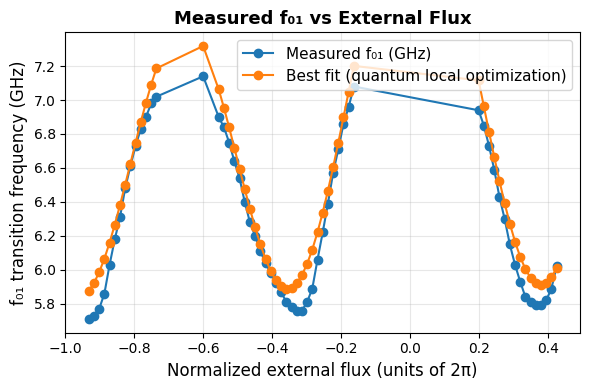

Phi_e_initial_opt = [[ 0.67465994  0.67792201]
 [-0.01976773 -0.01965281]
 [-0.6878894  -0.6881193 ]]


In [17]:
quantum_result = get_freq_vs_flux(phi_e_initial = phi_e_initial_opt, phi_ext_sweep = DC_x, phi_total_mag=2.0, N_opt=40, N_fine=1000, N_potential=3, EL=EL_opt, EJ=EJ_opt, EC=EC_opt, n_levels=3, order=5, n_starts=1, seed=0, options={"maxiter": 100, "gtol": 1e-9})
E_sweep = quantum_result['E_sweep']
f01 = E_sweep[:, 1] - E_sweep[:, 0]
figure = plt.figure(figsize=(6, 4))
plt.plot(DC_x, f01_data_GHz, 'o-', label='Measured f₀₁ (GHz)', color='C0')
plt.plot(DC_x, f01, '-o', label='Best fit (quantum local optimization)', color='C1')
plt.xlabel('Normalized external flux (units of 2π)', fontsize=12)
plt.ylabel('f₀₁ transition frequency (GHz)', fontsize=12)
plt.title('Measured f₀₁ vs External Flux', fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f"Phi_e_initial_opt = {phi_e_initial_opt}")